## Install & Import

In [ ]:
!pip install xgboost imbalanced-learn scikit-learn pandas numpy scipy --quiet

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, cohen_kappa_score, balanced_accuracy_score)
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from scipy.stats import wilcoxon

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
import pandas as pd
import numpy as np
import random
from google.colab import drive

# Step 0: Install required packages
!pip install networkx matplotlib numpy pandas scikit-learn xgboost

# Step 1: Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/maternal.csv")


In [ ]:
df.describe()

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# ── ACTUAL DATA LOADING ──────────────────────────
df = pd.read_csv("/content/drive/MyDrive/Dataset/maternal.csv")

X = df.drop(['ID', 'target'], axis=1)

# Integer-encode labels
le = LabelEncoder()
y = pd.Series(le.fit_transform(df['target']), name='target')
Class_names = list(le.classes_)

# Apply Label Encoding to categorical features in X
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Classes: {Class_names}')
print(f'Class distribution:')
print(pd.Series(le.inverse_transform(y)).value_counts())

# ── Feature importance for reference / display only ───────────────────
# NOTE: top_features below is computed on the full dataset for display
# purposes ONLY.  All CV functions below recompute feature importance
# INSIDE each training fold to avoid feature-selection data leakage.
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)
importances = rf_selector.feature_importances_
top_features = X.columns[np.argsort(importances)[-10:]].tolist()

print(f'\nReference top features (full-data, display only): {top_features}')
print('(All CV runs recompute feature selection inside each fold.)')

Dataset: 1014 samples, 6 features
Classes: [np.int64(0), np.int64(1), np.int64(2)]
Class distribution:
0    406
1    336
2    272
Name: count, dtype: int64

Reference top features (full-data, display only): ['BodyTemp', 'HeartRate', 'DiastolicBP', 'Age', 'SystolicBP', 'BS']
(All CV runs recompute feature selection inside each fold.)


In [ ]:
df.describe()


,ID,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,target
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,507.500000,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775,0.867850
std,292.860888,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702,0.807353
min,1.000000,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,0.000000
25%,254.250000,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,0.000000
50%,507.500000,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,1.000000
75%,760.750000,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000,2.000000
max,1014.000000,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,2.000000


## Shared Helper Functions

In [5]:
def medoid_of_group(X_group):
    arr = np.asarray(X_group)
    if len(arr) == 1:
        return 0, arr[0]
    centroid = np.mean(arr, axis=0)
    dists = np.linalg.norm(arr - centroid, axis=1)
    idx = int(np.argmin(dists))
    return idx, arr[idx]


def get_top_features_in_fold(X_tr, y_tr, n_top=10, random_state=42):
    """
    Feature selection performed INSIDE a CV fold on training data only.
    Returns the top-n feature names by RF impurity importance.
    This prevents feature-selection data leakage.
    """
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(X_tr, y_tr)
    imp = rf.feature_importances_
    return X_tr.columns[np.argsort(imp)[-n_top:]].tolist()


def get_wider_features_in_fold(X_tr, y_tr, random_state=42):
    """
    Wider feature set computed inside a CV fold.
    Keeps features with importance >= mean - 0.5*std.
    """
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(X_tr, y_tr)
    imp = rf.feature_importances_
    threshold = imp.mean() - 0.5 * imp.std()
    return X_tr.columns[imp >= threshold].tolist()


def calculate_cv_metrics(y_true, y_pred, Class_names):
    all_labels = np.arange(len(Class_names))
    metrics = {
        'Accuracy':               accuracy_score(y_true, y_pred),
        'Balanced Accuracy':      balanced_accuracy_score(y_true, y_pred),
        'Precision (Weighted)':   precision_score(y_true, y_pred, average='weighted', zero_division=0, labels=all_labels),
        'Precision (Macro)':      precision_score(y_true, y_pred, average='macro',    zero_division=0, labels=all_labels),
        'Recall (Weighted)':      recall_score(y_true, y_pred,    average='weighted', zero_division=0, labels=all_labels),
        'Recall (Macro)':         recall_score(y_true, y_pred,    average='macro',    zero_division=0, labels=all_labels),
        'F1 Score (Weighted)':    f1_score(y_true, y_pred,        average='weighted', zero_division=0, labels=all_labels),
        'F1 Score (Macro)':       f1_score(y_true, y_pred,        average='macro',    zero_division=0, labels=all_labels),
    }
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        metrics["Cohen's Kappa"] = cohen_kappa_score(y_true, y_pred, labels=all_labels)
    recall_per_Class = recall_score(y_true, y_pred, average=None, zero_division=0, labels=all_labels)
    for i, cn in enumerate(Class_names):
        metrics[f'Recall_{cn}'] = recall_per_Class[i]
    return metrics


def aggregate_fold_metrics(fold_metrics_list):
    df_tmp = pd.DataFrame(fold_metrics_list)
    final = {}
    for col in df_tmp.columns:
        final[f'{col}_mean'] = df_tmp[col].mean()
        final[f'{col}_std']  = df_tmp[col].std()
    # Store raw per-fold accuracies for Wilcoxon test
    final['_fold_accuracies'] = df_tmp['Accuracy'].tolist()
    return final


def format_results_df(results_list):
    rows = []
    for r in results_list:
        row = {'Strategy': r['Strategy'], 'Model': r['Model']}
        for k, v in r.items():
            if k.endswith('_mean'):
                metric = k.replace('_mean', '')
                std = r.get(k.replace('_mean', '_std'), 0)
                row[metric] = f"{v:.4f} ± {std:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)


# ── Models to evaluate ────────────────────────────────────────────────────
# NearestCentroid is a direct reviewer-requested baseline.
# It Classifies by assigning each sample to the Class whose centroid is closest —
# making it the simplest possible prototype-distance Classifier.
models_to_evaluate = {
    'RandomForest':    (RandomForestClassifier, {'n_estimators': 40, 'criterion':'entropy','random_state': 42,  'max_depth':5,
    'max_features':4,
    'min_samples_leaf':10}),
    'SVM':             (SVC,                    {'random_state': 42}),
    'KNN':             (KNeighborsClassifier,   {}),
    'XGBoost':         (XGBClassifier,          {'objective': 'multi:softmax',
                                                  'num_Class': len(Class_names),
                                                  'random_state': 42, 'verbosity': 0}),
    'NearestCentroid': (NearestCentroid,        {}),   # reviewer-requested baseline
}

N_SPLITS     = 10
RANDOM_STATE = 42
all_results  = []   # collects results from every strategy

print('Helpers ready. Models:', list(models_to_evaluate.keys()))

Helpers ready. Models: ['RandomForest', 'SVM', 'KNN', 'XGBoost', 'NearestCentroid']


In [6]:
def run_all_features_baseline(model_Class, model_params, X_data, y_data,
                                Class_names, n_splits=10, random_state=42):
    """
    Baseline: all original features, no augmentation.
    NearestCentroid uses StandardScaler (requires numeric, cannot use Class_weight).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[all_cols]),
                                 columns=all_cols, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[all_cols]),
                                 columns=all_cols, index=X_te.index)

        model = model_Class(**model_params)
        model.fit(X_tr_sc, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Baseline: All Features...')
all_features_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_all_features_baseline(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Baseline: All Features'
    res['Model']    = mname
    all_features_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')

Running Baseline: All Features...
  RandomForest: Acc=0.6983, F1_mac=0.6707
  SVM: Acc=0.7041, F1_mac=0.6932
  KNN: Acc=0.6755, F1_mac=0.6765
  XGBoost: Acc=0.8658, F1_mac=0.8693
  NearestCentroid: Acc=0.5907, F1_mac=0.5975
Done.


---
## Baseline — Original Augmented (Centroid + Medoid on Filtered Features)

Reproduces the original `augmented_cm` strategy so we have a baseline to compare each fix against.

In [7]:
def run_baseline_augmented(model_Class, model_params, X_data, y_data,
                            Class_names, n_splits=10, random_state=42):
    """
    Augmented_cm: centroid + medoid distances on filtered features.
    Feature selection is now performed INSIDE each CV fold to prevent leakage.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # ── Feature selection INSIDE fold (no leakage) ────────────────────────
        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        # NearestCentroid does not support augmentation; run plain scaled features
        if model_Class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_Class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        # Centroids and medoids from training fold only
        train_sc = X_tr_sc.copy(); train_sc['Class'] = y_tr
        grouped  = train_sc.groupby('Class')
        centroids = grouped[fold_top_feats].mean()
        medoids   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[fold_top_feats])[1], index=fold_top_feats)
             for cls, g in grouped}).T

        def augment(X_sc):
            X_aug = X_sc.copy()
            for cls in centroids.index:
                X_aug[f'dist_centroid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - centroids.loc[cls].values, axis=1)
                X_aug[f'dist_medoid_{cls}']   = np.linalg.norm(
                    X_sc[fold_top_feats].values - medoids.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment(X_tr_sc)
        X_te_aug = augment(X_te_sc)

        model = model_Class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running baseline augmented (original augmented_cm — in-fold feature selection)...')
baseline_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_baseline_augmented(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Augmented_cm'
    res['Model']    = mname
    baseline_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'BalAcc={res["Balanced Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')

print('Done.')

Running baseline augmented (original augmented_cm — in-fold feature selection)...
  RandomForest: Acc=0.7297, BalAcc=0.7254, F1_mac=0.7161
  SVM: Acc=0.6824, BalAcc=0.6781, F1_mac=0.6697
  KNN: Acc=0.6824, BalAcc=0.6812, F1_mac=0.6862
  XGBoost: Acc=0.8639, BalAcc=0.8689, F1_mac=0.8669
  NearestCentroid: Acc=0.5907, BalAcc=0.5963, F1_mac=0.5975
Done.


---
## Ablation A — Centroid-Only Augmentation (Filtered Features)

**Purpose (Reviewer-requested ablation):** Isolate the contribution of *centroid distances alone*
on the filtered feature set, without any medoid distances.
This lets us answer: does the medoid add anything beyond what the centroid already provides?

Centroids are computed **strictly within each training fold** to avoid data leakage.


In [8]:
def run_centroid_only(model_Class, model_params, X_data, y_data,
                      Class_names, n_splits=10, random_state=42):
    """
    Ablation A: Centroid distances ONLY on filtered features.
    Feature selection performed INSIDE each fold (no leakage).
    NearestCentroid runs on scaled top features without augmentation.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_Class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_Class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        train_sc = X_tr_sc.copy()
        train_sc['Class'] = y_tr
        centroids = train_sc.groupby('Class')[fold_top_feats].mean()

        def augment_centroid_only(X_sc):
            X_aug = X_sc.copy()
            for cls in centroids.index:
                X_aug[f'dist_centroid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - centroids.loc[cls].values, axis=1)
            return X_aug

        X_tr_aug = augment_centroid_only(X_tr_sc)
        X_te_aug = augment_centroid_only(X_te_sc)

        model = model_Class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Ablation A — Centroid-only (in-fold feature selection)...')
centroid_only_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_centroid_only(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Ablation A: Centroid-Only'
    res['Model']    = mname
    centroid_only_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}, ' +
          f'Kappa={res["Cohen\'s Kappa_mean"]:.4f}')
print('Done.')

Running Ablation A — Centroid-only (in-fold feature selection)...
  RandomForest: Acc=0.7189, F1_mac=0.6982, Kappa=0.5661
  SVM: Acc=0.6844, F1_mac=0.6722, Kappa=0.5144
  KNN: Acc=0.6883, F1_mac=0.6909, Kappa=0.5215
  XGBoost: Acc=0.8589, F1_mac=0.8629, Kappa=0.7861
  NearestCentroid: Acc=0.5907, F1_mac=0.5975, Kappa=0.3777
Done.


---
## Ablation B — Medoid-Only Augmentation (Filtered Features)

**Purpose (Reviewer-requested ablation):** Isolate the contribution of *medoid distances alone*
on the filtered feature set, without any centroid distances.
The medoid is the actual training sample closest to the Class centroid,
making it more robust to outliers than the mean centroid.

Medoids are computed **strictly within each training fold** to avoid data leakage.


In [9]:
def run_medoid_only(model_Class, model_params, X_data, y_data,
                    Class_names, n_splits=10, random_state=42):
    """
    Ablation B: Medoid distances ONLY on filtered features.
    Feature selection performed INSIDE each fold (no leakage).
    NearestCentroid runs on scaled top features without augmentation.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_Class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_Class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        train_sc = X_tr_sc.copy()
        train_sc['Class'] = y_tr
        grouped = train_sc.groupby('Class')
        medoids = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[fold_top_feats])[1], index=fold_top_feats)
             for cls, g in grouped}).T

        def augment_medoid_only(X_sc):
            X_aug = X_sc.copy()
            for cls in medoids.index:
                X_aug[f'dist_medoid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - medoids.loc[cls].values, axis=1)
            return X_aug

        X_tr_aug = augment_medoid_only(X_tr_sc)
        X_te_aug = augment_medoid_only(X_te_sc)

        model = model_Class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Ablation B — Medoid-only (in-fold feature selection)...')
medoid_only_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_medoid_only(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Ablation B: Medoid-Only'
    res['Model']    = mname
    medoid_only_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}, ' +
          f'Kappa={res["Cohen\'s Kappa_mean"]:.4f}')
print('Done.')

Running Ablation B — Medoid-only (in-fold feature selection)...
  RandomForest: Acc=0.7160, F1_mac=0.6966, Kappa=0.5624
  SVM: Acc=0.6815, F1_mac=0.6688, Kappa=0.5101
  KNN: Acc=0.6765, F1_mac=0.6800, Kappa=0.5028
  XGBoost: Acc=0.8658, F1_mac=0.8695, Kappa=0.7968
  NearestCentroid: Acc=0.5907, F1_mac=0.5975, Kappa=0.3777
Done.


---
## Ablation Summary — Centroid vs Medoid vs Combined

Side-by-side comparison of the three filtered-feature augmentation variants:

| Strategy | Distance features added |
|---|---|
| Baseline augmented\_cm | centroid + medoid |
| Ablation A: Centroid-Only | centroid only |
| Ablation B: Medoid-Only | medoid only |

This directly isolates each component's contribution as required by the reviewer.


In [10]:
# ── Ablation comparison table ────────────────────────────────────────────────
ablation_strategies = ['Augmented_cm', 'Ablation A: Centroid-Only', 'Ablation B: Medoid-Only']
ablation_pool = [r for r in all_results if r['Strategy'] in ablation_strategies]

# Deduplicate: keep last occurrence of each (Strategy, Model) pair
seen_keys = set()
ablation_dedup = []
for r in reversed(ablation_pool):
    key = (r['Strategy'], r['Model'])
    if key not in seen_keys:
        seen_keys.add(key)
        ablation_dedup.insert(0, r)

ablation_df = format_results_df(ablation_dedup)

display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in Class_names]
)
display_cols = [c for c in display_cols if c in ablation_df.columns]

print('\n=== Ablation: Centroid-Only vs Medoid-Only vs Combined (mean ± std, 5-fold CV) ===')
pd.set_option('display.max_colwidth', 42)
pd.set_option('display.width', 220)
display(ablation_df[display_cols].sort_values(['Model', 'Strategy']))

# Delta table relative to Augmented_cm
print('\n── Delta relative to Augmented_cm (Centroid + Medoid) ──')
for model_name in sorted({r['Model'] for r in ablation_dedup}):
    sub = [r for r in ablation_dedup if r['Model'] == model_name]
    base = next((r for r in sub if r['Strategy'] == 'Augmented_cm'), None)
    if not base:
        continue
    print(f'\n{model_name}:')
    for r in sorted(sub, key=lambda x: x['Strategy']):
        d_acc   = r['Accuracy_mean']              - base['Accuracy_mean']
        d_bal   = r['Balanced Accuracy_mean']     - base['Balanced Accuracy_mean']
        d_f1    = r['F1 Score (Macro)_mean']      - base['F1 Score (Macro)_mean']
        d_kappa = r["Cohen's Kappa_mean"]        - base["Cohen's Kappa_mean"]
        print(f'  {r["Strategy"]:<42}  '
              f'Acc={r["Accuracy_mean"]:.4f} ({d_acc:+.4f})  '
              f'BalAcc={r["Balanced Accuracy_mean"]:.4f} ({d_bal:+.4f})  '
              f'F1_mac={r["F1 Score (Macro)_mean"]:.4f} ({d_f1:+.4f})  '
              f'Kappa={r["Cohen's Kappa_mean"]:.4f} ({d_kappa:+.4f})')



=== Ablation: Centroid-Only vs Medoid-Only vs Combined (mean ± std, 5-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_0,Recall_1,Recall_2
7,Ablation A: Centroid-Only,KNN,0.6883 ± 0.0432,0.6870 ± 0.0446,0.6909 ± 0.0406,0.6854 ± 0.0412,0.5215 ± 0.0678,0.7809 ± 0.0785,0.5152 ± 0.0715,0.7649 ± 0.0859
12,Ablation B: Medoid-Only,KNN,0.6765 ± 0.0482,0.6745 ± 0.0501,0.6800 ± 0.0446,0.6746 ± 0.0451,0.5028 ± 0.0754,0.7709 ± 0.0756,0.5059 ± 0.0562,0.7467 ± 0.0909
2,Augmented_cm,KNN,0.6824 ± 0.0480,0.6812 ± 0.0491,0.6862 ± 0.0444,0.6803 ± 0.0450,0.5121 ± 0.0746,0.7735 ± 0.0801,0.5088 ± 0.0513,0.7611 ± 0.0819
9,Ablation A: Centroid-Only,NearestCentroid,0.5907 ± 0.0364,0.5963 ± 0.0403,0.5975 ± 0.0385,0.5916 ± 0.0376,0.3777 ± 0.0580,0.6059 ± 0.0602,0.4851 ± 0.0987,0.6980 ± 0.1071
14,Ablation B: Medoid-Only,NearestCentroid,0.5907 ± 0.0364,0.5963 ± 0.0403,0.5975 ± 0.0385,0.5916 ± 0.0376,0.3777 ± 0.0580,0.6059 ± 0.0602,0.4851 ± 0.0987,0.6980 ± 0.1071
4,Augmented_cm,NearestCentroid,0.5907 ± 0.0364,0.5963 ± 0.0403,0.5975 ± 0.0385,0.5916 ± 0.0376,0.3777 ± 0.0580,0.6059 ± 0.0602,0.4851 ± 0.0987,0.6980 ± 0.1071
5,Ablation A: Centroid-Only,RandomForest,0.7189 ± 0.0197,0.7120 ± 0.0216,0.6982 ± 0.0214,0.6956 ± 0.0220,0.5661 ± 0.0311,0.9241 ± 0.0589,0.3816 ± 0.0695,0.8303 ± 0.0769
10,Ablation B: Medoid-Only,RandomForest,0.7160 ± 0.0415,0.7104 ± 0.0423,0.6966 ± 0.0458,0.6943 ± 0.0467,0.5624 ± 0.0648,0.9068 ± 0.0625,0.3903 ± 0.0839,0.8341 ± 0.0767
0,Augmented_cm,RandomForest,0.7297 ± 0.0225,0.7254 ± 0.0245,0.7161 ± 0.0260,0.7137 ± 0.0259,0.5844 ± 0.0355,0.8943 ± 0.0564,0.4403 ± 0.0648,0.8415 ± 0.0677
6,Ablation A: Centroid-Only,SVM,0.6844 ± 0.0404,0.6806 ± 0.0415,0.6722 ± 0.0431,0.6686 ± 0.0422,0.5144 ± 0.0622,0.8474 ± 0.0735,0.3931 ± 0.0790,0.8012 ± 0.0771



── Delta relative to Augmented_cm (Centroid + Medoid) ──

KNN:
  Ablation A: Centroid-Only                   Acc=0.6883 (+0.0059)  BalAcc=0.6870 (+0.0058)  F1_mac=0.6909 (+0.0047)  Kappa=0.5215 (+0.0093)
  Ablation B: Medoid-Only                     Acc=0.6765 (-0.0059)  BalAcc=0.6745 (-0.0067)  F1_mac=0.6800 (-0.0062)  Kappa=0.5028 (-0.0093)
  Augmented_cm                                Acc=0.6824 (+0.0000)  BalAcc=0.6812 (+0.0000)  F1_mac=0.6862 (+0.0000)  Kappa=0.5121 (+0.0000)

NearestCentroid:
  Ablation A: Centroid-Only                   Acc=0.5907 (+0.0000)  BalAcc=0.5963 (+0.0000)  F1_mac=0.5975 (+0.0000)  Kappa=0.3777 (+0.0000)
  Ablation B: Medoid-Only                     Acc=0.5907 (+0.0000)  BalAcc=0.5963 (+0.0000)  F1_mac=0.5975 (+0.0000)  Kappa=0.3777 (+0.0000)
  Augmented_cm                                Acc=0.5907 (+0.0000)  BalAcc=0.5963 (+0.0000)  F1_mac=0.5975 (+0.0000)  Kappa=0.3777 (+0.0000)

RandomForest:
  Ablation A: Centroid-Only                   Acc=0.7189 

---
## Nearest Centroid Classifier — Reviewer-Requested Baseline

The **Nearest Centroid Classifier (NCC)** assigns each sample to the Class whose
centroid is nearest (Euclidean distance on standardised features). It is included
as a reviewer-requested baseline because:

- It is the simplest possible prototype-distance Classifier
- It directly evaluates whether raw centroid proximity alone suffices for Classification
- It provides a meaningful lower-bound comparison for the proposed augmentation

NCC results appear in all strategy tables under the `NearestCentroid` model row.
Because NCC's own decision rule IS centroid distance, augmenting its features
with centroid/medoid distances would be circular — so NCC runs on plain scaled features
in all strategies (which is the correct and most informative comparison).


---
## Fix 1 — Distances Computed on ALL Features (Not Just Filtered)

**Problem:** The original code scales and computes centroid/medoid distances only from `top_features` — features the model already sees directly. This makes the distance features redundant (especially for tree models).

**Fix:** Scale the **entire** feature matrix and compute distances in that full space. The distances now encode signal from features that were otherwise dropped, giving the model genuinely new geometric information.

The final model input is: `top_features (scaled)` + `distances computed in full-feature space`.

In [11]:
def run_fix1_full_space_distances(model_Class, model_params, X_data, y_data,
                                   Class_names, n_splits=10, random_state=42):
    """
    Fix 1: Centroid/medoid distances in FULL feature space.
    Feature selection for filtered base performed INSIDE each fold.
    NearestCentroid: uses all-features scaled (no augmentation needed).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # In-fold feature selection
        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_Class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[all_cols])
            X_te_sc = scaler.transform(X_te[all_cols])
            model = model_Class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))
            continue

        full_scaler  = StandardScaler()
        X_tr_full_sc = full_scaler.fit_transform(X_tr[all_cols])
        X_te_full_sc = full_scaler.transform(X_te[all_cols])

        train_full_df = pd.DataFrame(X_tr_full_sc, columns=all_cols, index=X_tr.index)
        train_full_df['Class'] = y_tr
        grouped_full   = train_full_df.groupby('Class')
        centroids_full = grouped_full[all_cols].mean()
        medoids_full   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[all_cols])[1], index=all_cols)
             for cls, g in grouped_full}).T

        filt_scaler  = StandardScaler()
        X_tr_filt_sc = pd.DataFrame(filt_scaler.fit_transform(X_tr[fold_top_feats]),
                                     columns=fold_top_feats, index=X_tr.index)
        X_te_filt_sc = pd.DataFrame(filt_scaler.transform(X_te[fold_top_feats]),
                                     columns=fold_top_feats, index=X_te.index)

        def augment_full(X_filt_sc, X_full_sc_arr):
            X_aug = X_filt_sc.copy()
            for cls in centroids_full.index:
                X_aug[f'dist_full_centroid_{cls}'] = np.linalg.norm(
                    X_full_sc_arr - centroids_full.loc[cls].values, axis=1)
                X_aug[f'dist_full_medoid_{cls}']   = np.linalg.norm(
                    X_full_sc_arr - medoids_full.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment_full(X_tr_filt_sc, X_tr_full_sc)
        X_te_aug = augment_full(X_te_filt_sc, X_te_full_sc)

        model = model_Class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Fix 1 — distances in full feature space (in-fold selection)...')
fix1_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_fix1_full_space_distances(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Fix 1: Full-space distances'
    res['Model']    = mname
    fix1_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')

Running Fix 1 — distances in full feature space (in-fold selection)...
  RandomForest: Acc=0.7297, F1_mac=0.7161
  SVM: Acc=0.6824, F1_mac=0.6697
  KNN: Acc=0.6824, F1_mac=0.6862
  XGBoost: Acc=0.8639, F1_mac=0.8669
  NearestCentroid: Acc=0.5907, F1_mac=0.5975
Done.


---
## Fix 2 — Wider Filtered Feature Set

**Problem:** The original filtering is too aggressive — your results show a 7% accuracy drop from "All Features" to "Filtered Features". The augmentation then tries to recover signal that was already discarded.

**Fix:** Use a softer importance threshold (`mean − 0.5 × std` instead of a hard top-N cutoff). This keeps more borderline-useful features while still discarding true noise.

We also build on Fix 1 (full-space distances), so this is a cumulative improvement.

In [12]:
def run_fix2_wider_features(model_Class, model_params, X_data, y_data,
                             Class_names, n_splits=10, random_state=42):
    """
    Fix 2: Wider filtered features + full-space distances.
    Wider feature threshold computed INSIDE each fold (no leakage).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # In-fold wider feature selection
        wider_feats = get_wider_features_in_fold(X_tr, y_tr, random_state=random_state)

        if model_Class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[wider_feats])
            X_te_sc = scaler.transform(X_te[wider_feats])
            model = model_Class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))
            continue

        full_scaler  = StandardScaler()
        X_tr_full_sc = full_scaler.fit_transform(X_tr[all_cols])
        X_te_full_sc = full_scaler.transform(X_te[all_cols])

        train_full_df = pd.DataFrame(X_tr_full_sc, columns=all_cols, index=X_tr.index)
        train_full_df['Class'] = y_tr
        grouped_full   = train_full_df.groupby('Class')
        centroids_full = grouped_full[all_cols].mean()
        medoids_full   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[all_cols])[1], index=all_cols)
             for cls, g in grouped_full}).T

        filt_scaler  = StandardScaler()
        X_tr_filt_sc = pd.DataFrame(filt_scaler.fit_transform(X_tr[wider_feats]),
                                     columns=wider_feats, index=X_tr.index)
        X_te_filt_sc = pd.DataFrame(filt_scaler.transform(X_te[wider_feats]),
                                     columns=wider_feats, index=X_te.index)

        def augment(X_filt_sc, X_full_sc_arr):
            X_aug = X_filt_sc.copy()
            for cls in centroids_full.index:
                X_aug[f'dist_full_centroid_{cls}'] = np.linalg.norm(
                    X_full_sc_arr - centroids_full.loc[cls].values, axis=1)
                X_aug[f'dist_full_medoid_{cls}']   = np.linalg.norm(
                    X_full_sc_arr - medoids_full.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment(X_tr_filt_sc, X_tr_full_sc)
        X_te_aug = augment(X_te_filt_sc, X_te_full_sc)

        model = model_Class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Fix 2 — wider feature set + full-space distances (in-fold selection)...')
fix2_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_fix2_wider_features(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Fix 2: Wider features'
    res['Model']    = mname
    fix2_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')

Running Fix 2 — wider feature set + full-space distances (in-fold selection)...
  RandomForest: Acc=0.7149, F1_mac=0.6962
  SVM: Acc=0.6567, F1_mac=0.6343
  KNN: Acc=0.6962, F1_mac=0.7029
  XGBoost: Acc=0.8629, F1_mac=0.8666
  NearestCentroid: Acc=0.5571, F1_mac=0.5694
Done.


---
## Summary — All Strategies Compared

In [13]:
# ── Final comprehensive summary ────────────────────────────────────────────
all_results_df = pd.DataFrame(all_results)
all_results_processed = (all_results_df
    .drop_duplicates(subset=['Strategy', 'Model'], keep='last')
    .to_dict(orient='records'))

summary_df = format_results_df(all_results_processed)

strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]

summary_df['Strategy'] = pd.Categorical(summary_df['Strategy'],
                                         categories=strategy_order, ordered=True)

display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in Class_names]
)
display_cols = [c for c in display_cols if c in summary_df.columns]

pd.set_option('display.max_colwidth', 42)
pd.set_option('display.width', 220)
print('=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===')
display(summary_df[display_cols].sort_values(['Model', 'Strategy']))

# Numeric delta table
numeric_rows = []
for r in all_results_processed:
    numeric_rows.append({
        'Strategy':      r['Strategy'],
        'Model':         r['Model'],
        'Accuracy':      r['Accuracy_mean'],
        'Balanced Acc':  r['Balanced Accuracy_mean'],
        'F1 Macro':      r['F1 Score (Macro)_mean'],
        "Cohen's Kappa": r["Cohen's Kappa_mean"],
        f'Recall_{Class_names[0]}': r[f'Recall_{Class_names[0]}_mean'],
    })

numeric_df = pd.DataFrame(numeric_rows)
numeric_df['Strategy'] = pd.Categorical(numeric_df['Strategy'],
                                         categories=strategy_order, ordered=True)

print('\n── Delta vs Baseline: All Features (per model) ──')
for model_name in numeric_df['Model'].unique():
    sub = numeric_df[numeric_df['Model'] == model_name].sort_values('Strategy')
    ref = sub.loc[sub['Strategy'] == 'Baseline: All Features', 'Accuracy'].values
    if not len(ref):
        continue
    ref = ref[0]
    print(f'\n{model_name}:')
    for _, row in sub.iterrows():
        d = row['Accuracy'] - ref
        print(f'  {row["Strategy"]:<42}  Acc={row["Accuracy"]:.4f} ({d:+.4f})  ' +
              f'F1_mac={row["F1 Macro"]:.4f}  Kappa={row["Cohen\'s Kappa"]:.4f}  ' +
              f'{Class_names[0]}_Recall={row[f"Recall_{Class_names[0]}"]:.4f}')

=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_0,Recall_1,Recall_2
2,Baseline: All Features,KNN,0.6755 ± 0.0491,0.6742 ± 0.0498,0.6765 ± 0.0454,0.6707 ± 0.0467,0.5014 ± 0.0771,0.7758 ± 0.0863,0.4854 ± 0.0978,0.7615 ± 0.0895
7,Augmented_cm,KNN,0.6824 ± 0.0480,0.6812 ± 0.0491,0.6862 ± 0.0444,0.6803 ± 0.0450,0.5121 ± 0.0746,0.7735 ± 0.0801,0.5088 ± 0.0513,0.7611 ± 0.0819
12,Ablation A: Centroid-Only,KNN,0.6883 ± 0.0432,0.6870 ± 0.0446,0.6909 ± 0.0406,0.6854 ± 0.0412,0.5215 ± 0.0678,0.7809 ± 0.0785,0.5152 ± 0.0715,0.7649 ± 0.0859
17,Ablation B: Medoid-Only,KNN,0.6765 ± 0.0482,0.6745 ± 0.0501,0.6800 ± 0.0446,0.6746 ± 0.0451,0.5028 ± 0.0754,0.7709 ± 0.0756,0.5059 ± 0.0562,0.7467 ± 0.0909
22,Fix 1: Full-space distances,KNN,0.6824 ± 0.0480,0.6812 ± 0.0491,0.6862 ± 0.0444,0.6803 ± 0.0450,0.5121 ± 0.0746,0.7735 ± 0.0801,0.5088 ± 0.0513,0.7611 ± 0.0819
27,Fix 2: Wider features,KNN,0.6962 ± 0.0294,0.6963 ± 0.0301,0.7029 ± 0.0278,0.6957 ± 0.0270,0.5339 ± 0.0447,0.7635 ± 0.0787,0.5536 ± 0.0597,0.7720 ± 0.0849
4,Baseline: All Features,NearestCentroid,0.5907 ± 0.0364,0.5963 ± 0.0403,0.5975 ± 0.0385,0.5916 ± 0.0376,0.3777 ± 0.0580,0.6059 ± 0.0602,0.4851 ± 0.0987,0.6980 ± 0.1071
9,Augmented_cm,NearestCentroid,0.5907 ± 0.0364,0.5963 ± 0.0403,0.5975 ± 0.0385,0.5916 ± 0.0376,0.3777 ± 0.0580,0.6059 ± 0.0602,0.4851 ± 0.0987,0.6980 ± 0.1071
14,Ablation A: Centroid-Only,NearestCentroid,0.5907 ± 0.0364,0.5963 ± 0.0403,0.5975 ± 0.0385,0.5916 ± 0.0376,0.3777 ± 0.0580,0.6059 ± 0.0602,0.4851 ± 0.0987,0.6980 ± 0.1071
19,Ablation B: Medoid-Only,NearestCentroid,0.5907 ± 0.0364,0.5963 ± 0.0403,0.5975 ± 0.0385,0.5916 ± 0.0376,0.3777 ± 0.0580,0.6059 ± 0.0602,0.4851 ± 0.0987,0.6980 ± 0.1071



── Delta vs Baseline: All Features (per model) ──

RandomForest:
  Baseline: All Features                      Acc=0.6983 (+0.0000)  F1_mac=0.6707  Kappa=0.5332  0_Recall=0.9262
  Augmented_cm                                Acc=0.7297 (+0.0315)  F1_mac=0.7161  Kappa=0.5844  0_Recall=0.8943
  Ablation A: Centroid-Only                   Acc=0.7189 (+0.0207)  F1_mac=0.6982  Kappa=0.5661  0_Recall=0.9241
  Ablation B: Medoid-Only                     Acc=0.7160 (+0.0177)  F1_mac=0.6966  Kappa=0.5624  0_Recall=0.9068
  Fix 1: Full-space distances                 Acc=0.7297 (+0.0315)  F1_mac=0.7161  Kappa=0.5844  0_Recall=0.8943
  Fix 2: Wider features                       Acc=0.7149 (+0.0167)  F1_mac=0.6962  Kappa=0.5601  0_Recall=0.9066

SVM:
  Baseline: All Features                      Acc=0.7041 (+0.0000)  F1_mac=0.6932  Kappa=0.5447  0_Recall=0.8573
  Augmented_cm                                Acc=0.6824 (-0.0217)  F1_mac=0.6697  Kappa=0.5114  0_Recall=0.8474
  Ablation A: Centroid-O

In [14]:
all_results_df = pd.DataFrame(all_results)
# Keep the last entry for each unique (Strategy, Model) combination.
# Changing to keep='first' to ensure earlier valid runs are not overwritten by later accidental duplicates.
all_results_processed = all_results_df.drop_duplicates(subset=['Strategy', 'Model'], keep='first').to_dict(orient='records')

summary_df = format_results_df(all_results_processed)

# Define custom order for strategies
strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]

# Define custom order for models
model_order = [
    'RandomForest',
    'NearestCentroid',
    'KNN',
    'XGBoost',
    'SVM'
]

# Convert 'Strategy' column to categorical with custom order for summary_df
summary_df['Strategy'] = pd.Categorical(summary_df['Strategy'], categories=strategy_order, ordered=True)

# Convert 'Model' column to categorical with custom order for summary_df
summary_df['Model'] = pd.Categorical(summary_df['Model'], categories=model_order, ordered=True)

# Order columns nicely
display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in Class_names]
)
display_cols = [c for c in display_cols if c in summary_df.columns]

pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 200)
print('=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===')
display(summary_df[display_cols].sort_values(['Model', 'Strategy']))


# Numeric summary — mean values only for easy comparison
numeric_rows = []
for r in all_results_processed:
    numeric_rows.append({
        'Strategy':        r['Strategy'],
        'Model':           r['Model'],
        'Accuracy':        r['Accuracy_mean'],
        'Balanced Acc':    r['Balanced Accuracy_mean'],
        'F1 Macro':        r['F1 Score (Macro)_mean'],
        "Cohen's Kappa":   r["Cohen's Kappa_mean"],
        f'Recall_{Class_names[0]}': r[f'Recall_{Class_names[0]}_mean'],
    })

numeric_df = pd.DataFrame(numeric_rows)

# Convert 'Strategy' column to categorical with custom order for numeric_df
numeric_df['Strategy'] = pd.Categorical(numeric_df['Strategy'], categories=strategy_order, ordered=True)

# Convert 'Model' column to categorical with custom order for numeric_df
numeric_df['Model'] = pd.Categorical(numeric_df['Model'], categories=model_order, ordered=True)

print('\n── Accuracy gain vs Baseline: All Features (per model) ──')
# Sort numeric_df by Model and then by Strategy to ensure correct iteration order
for model_name in numeric_df.sort_values('Model')['Model'].unique():
    sub = numeric_df[numeric_df['Model'] == model_name].copy()
    baseline_acc = sub.loc[sub['Strategy'] == 'Baseline: All Features', 'Accuracy'].values
    if len(baseline_acc) == 0:
        print(f'  WARNING: Baseline: All Features results not found for {model_name}. Skipping delta comparison.')
        continue
    baseline_acc = baseline_acc[0]
    print(f'\n{model_name}:')
    # Sort 'sub' by the custom strategy order before iterating
    for _, row in sub.sort_values('Strategy').iterrows():
        delta = row['Accuracy'] - baseline_acc
        sign  = '+' if delta >= 0 else ''
        print(f"  {row['Strategy']:<40}  Acc={row['Accuracy']:.4f}  ({sign}{delta:.4f})  " +
              f"{(Class_names[0])} Recall={row[f'Recall_{Class_names[0]}']:.4f}")

=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_0,Recall_1,Recall_2
0,Baseline: All Features,RandomForest,0.6983 ± 0.0308,0.6908 ± 0.0319,0.6707 ± 0.0348,0.6677 ± 0.0354,0.5332 ± 0.0488,0.9262 ± 0.0474,0.3160 ± 0.0670,0.8303 ± 0.0663
5,Augmented_cm,RandomForest,0.7297 ± 0.0225,0.7254 ± 0.0245,0.7161 ± 0.0260,0.7137 ± 0.0259,0.5844 ± 0.0355,0.8943 ± 0.0564,0.4403 ± 0.0648,0.8415 ± 0.0677
10,Ablation A: Centroid-Only,RandomForest,0.7189 ± 0.0197,0.7120 ± 0.0216,0.6982 ± 0.0214,0.6956 ± 0.0220,0.5661 ± 0.0311,0.9241 ± 0.0589,0.3816 ± 0.0695,0.8303 ± 0.0769
15,Ablation B: Medoid-Only,RandomForest,0.7160 ± 0.0415,0.7104 ± 0.0423,0.6966 ± 0.0458,0.6943 ± 0.0467,0.5624 ± 0.0648,0.9068 ± 0.0625,0.3903 ± 0.0839,0.8341 ± 0.0767
20,Fix 1: Full-space distances,RandomForest,0.7297 ± 0.0225,0.7254 ± 0.0245,0.7161 ± 0.0260,0.7137 ± 0.0259,0.5844 ± 0.0355,0.8943 ± 0.0564,0.4403 ± 0.0648,0.8415 ± 0.0677
25,Fix 2: Wider features,RandomForest,0.7149 ± 0.0308,0.7095 ± 0.0325,0.6962 ± 0.0377,0.6930 ± 0.0376,0.5601 ± 0.0490,0.9066 ± 0.0440,0.3840 ± 0.0794,0.8378 ± 0.0530
4,Baseline: All Features,NearestCentroid,0.5907 ± 0.0364,0.5963 ± 0.0403,0.5975 ± 0.0385,0.5916 ± 0.0376,0.3777 ± 0.0580,0.6059 ± 0.0602,0.4851 ± 0.0987,0.6980 ± 0.1071
9,Augmented_cm,NearestCentroid,0.5907 ± 0.0364,0.5963 ± 0.0403,0.5975 ± 0.0385,0.5916 ± 0.0376,0.3777 ± 0.0580,0.6059 ± 0.0602,0.4851 ± 0.0987,0.6980 ± 0.1071
14,Ablation A: Centroid-Only,NearestCentroid,0.5907 ± 0.0364,0.5963 ± 0.0403,0.5975 ± 0.0385,0.5916 ± 0.0376,0.3777 ± 0.0580,0.6059 ± 0.0602,0.4851 ± 0.0987,0.6980 ± 0.1071
19,Ablation B: Medoid-Only,NearestCentroid,0.5907 ± 0.0364,0.5963 ± 0.0403,0.5975 ± 0.0385,0.5916 ± 0.0376,0.3777 ± 0.0580,0.6059 ± 0.0602,0.4851 ± 0.0987,0.6980 ± 0.1071



── Accuracy gain vs Baseline: All Features (per model) ──

RandomForest:
  Baseline: All Features                    Acc=0.6983  (+0.0000)  0 Recall=0.9262
  Augmented_cm                              Acc=0.7297  (+0.0315)  0 Recall=0.8943
  Ablation A: Centroid-Only                 Acc=0.7189  (+0.0207)  0 Recall=0.9241
  Ablation B: Medoid-Only                   Acc=0.7160  (+0.0177)  0 Recall=0.9068
  Fix 1: Full-space distances               Acc=0.7297  (+0.0315)  0 Recall=0.8943
  Fix 2: Wider features                     Acc=0.7149  (+0.0167)  0 Recall=0.9066

NearestCentroid:
  Baseline: All Features                    Acc=0.5907  (+0.0000)  0 Recall=0.6059
  Augmented_cm                              Acc=0.5907  (+0.0000)  0 Recall=0.6059
  Ablation A: Centroid-Only                 Acc=0.5907  (+0.0000)  0 Recall=0.6059
  Ablation B: Medoid-Only                   Acc=0.5907  (+0.0000)  0 Recall=0.6059
  Fix 1: Full-space distances               Acc=0.5907  (+0.0000)  0 Recall=0.

In [16]:
import pandas as pd
import numpy as np # Import numpy for np.mean and np.std
import warnings # Import warnings for warnings.catch_warnings and warnings.simplefilter
from scipy.stats import wilcoxon # Import wilcoxon for the test

def get_fold_accs(all_results_list, strategy, model_name):
    """
    Retrieves per-fold accuracies for a given strategy and model.
    """
    for res in all_results_list:
        if res.get('Strategy') == strategy and res.get('Model') == model_name:
            return res.get('_fold_accuracies', [])
    return []

print('=== Wilcoxon Signed-Rank Test: All Strategies vs Baseline: All Features ===')

# Re-create numeric_df and strategy_order to ensure availability
all_results_df = pd.DataFrame(all_results)
all_results_processed = (all_results_df
    .drop_duplicates(subset=['Strategy', 'Model'], keep='last')
    .to_dict(orient='records'))

strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]

# Define custom order for models
model_order = [
    'RandomForest',
    'NearestCentroid',
    'KNN',
    'XGBoost',
    'SVM'
]

numeric_rows = []
for r in all_results_processed:
    numeric_rows.append({
        'Strategy':      r['Strategy'],
        'Model':         r['Model'],
        'Accuracy':      r['Accuracy_mean'],
        'Balanced Acc':  r['Balanced Accuracy_mean'],
        'F1 Macro':      r['F1 Score (Macro)_mean'],
        "Cohen's Kappa": r["Cohen's Kappa_mean"],
        f'Recall_{Class_names[0]}': r[f'Recall_{Class_names[0]}_mean'],
    })

numeric_df = pd.DataFrame(numeric_rows)
numeric_df['Strategy'] = pd.Categorical(numeric_df['Strategy'],
                                         categories=strategy_order, ordered=True)

# Get all unique models from the processed results
models = sorted(numeric_df['Model'].unique())

alpha = 0.05 # Significance level

wilcoxon_results = []

for model_name in models:
    # Get baseline accuracies for the current model
    baseline_accs = get_fold_accs(all_results, 'Baseline: All Features', model_name)

    if not baseline_accs:
        # print(f'  WARNING: Baseline: All Features results not found for {model_name}. Skipping comparisons.')
        continue

    # Filter results for the current model, INCLUDING the baseline itself
    model_strategies = numeric_df[numeric_df['Model'] == model_name].sort_values('Strategy')

    for _, row in model_strategies.iterrows():
        strategy_name = row['Strategy']
        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)

        if strategy_accs:
            if strategy_name == 'Baseline: All Features':
                mean_diff = 0.0
                p_value = 1.0 # Not greater than itself in a one-sided 'greater' test
                significance = f'✗ Not significant (p={p_value:.4f})'
            else:
                try:
                    # Suppress warnings for identical arrays, as we handle ValueError explicitly
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        stat, p_value = wilcoxon(strategy_accs, baseline_accs, alternative='greater')
                    mean_diff = np.mean(strategy_accs) - np.mean(baseline_accs)

                    if p_value < alpha:
                        significance = f'✓ SIGNIFICANT (p={p_value:.4f})'
                    else:
                        significance = f'✗ Not significant (p={p_value:.4f})'
                except ValueError as e:
                    # This typically catches cases where all differences are zero (and not baseline itself)
                    # or arrays are identical, making wilcoxon unable to compute ranks.
                    mean_diff = np.mean(strategy_accs) - np.mean(baseline_accs) # Still calculate mean diff if possible
                    p_value = 'N/A' # Indicate that the test couldn't be performed meaningfully
                    significance = f'ERROR: {e}'

            wilcoxon_results.append({
                'Model': model_name,
                'Strategy': strategy_name,
                'Mean Difference (Strategy - Baseline)': f'{mean_diff:+.4f}',
                'P-value': f'{p_value:.4f}',
                'Significance (\u03b1=0.05)': significance
            })
        else:
            # print(f'  WARNING: Results for strategy \'{strategy_name}\' not found for {model_name}. Skipping test.')
            pass

# Display the tabulated results
wilcoxon_df = pd.DataFrame(wilcoxon_results)

# Sort by Model and then by Strategy
wilcoxon_df['Strategy'] = pd.Categorical(wilcoxon_df['Strategy'], categories=strategy_order, ordered=True)
wilcoxon_df['Model'] = pd.Categorical(wilcoxon_df['Model'], categories=model_order, ordered=True)
wilcoxon_df = wilcoxon_df.sort_values(by=['Model', 'Strategy'])

print('\n--- Tabulated Wilcoxon Signed-Rank Test Results ---')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'left')
display(wilcoxon_df)

# Re-add original specific prints for clarity
print('\n' + '='*70)
print('=== \u2605 PRIMARY RESULT: Fix 4 XGBoost vs All-Features XGBoost ===')

# The variables fix4_xgb_accs, baseline_xgb_accs, K_SUB are not defined in the provided context
# and seem to belong to a later part of the notebook or a different version.
# To avoid further NameErrors, I will comment out this section or use placeholder values
# if they are critical for the user's intent. For now, commenting out.

# if fix4_xgb_accs and baseline_xgb_accs:
#     print(f'Fix 4 XGBoost    per-fold accuracies : {[round(a,4) for a in fix4_xgb_accs]}')
#     print(f'All-Features XGB per-fold accuracies : {[round(a,4) for a in baseline_xgb_accs]}')
#     print(f'Fix 4 XGBoost    mean \u00b1 std : {np.mean(fix4_xgb_accs):.4f} \u00b1 {np.std(fix4_xgb_accs):.4f}')
#     print(f'All-Features XGB mean \u00b1 std : {np.mean(baseline_xgb_accs):.4f} \u00b1 {np.std(baseline_xgb_accs):.4f}')
#     print(f'Mean difference  (Fix4 - AllFeat)    : {np.mean(fix4_xgb_accs) - np.mean(baseline_xgb_accs):+.4f}')

#     # Two-sided test first
#     stat_two, p_two = wilcoxon(fix4_xgb_accs, baseline_xgb_accs, alternative='two-sided')
#     # One-sided (Fix4 > Baseline)
#     stat_one, p_one = wilcoxon(fix4_xgb_accs, baseline_xgb_accs, alternative='greater')

#     print(f'\nWilcoxon signed-rank test (two-sided): statistic={stat_two:.4f}, p={p_two:.4f}')
#     print(f'Wilcoxon signed-rank test (one-sided, Fix4>Baseline): statistic={stat_one:.4f}, p={p_one:.4f}')

#     alpha = 0.05
#     if p_two < alpha:
#         print(f'\n\u2713 Statistically SIGNIFICANT at \u03b1={alpha} (two-sided p={p_two:.4f})')
#         print('  Fix 4 XGBoost significantly differs from the All-Features baseline.')
#     else:
#         print(f'\n\u2717 Not significant at \u03b1={alpha} (two-sided p={p_two:.4f})')
#         print('  Note: With only 5 folds the Wilcoxon test has limited power.')
#         print('  A consistent positive mean difference still supports the method\'s direction.')

#     if p_one < alpha:
#         print(f'\n\u2713 One-sided test significant at \u03b1={alpha}: Fix 4 XGBoost > All-Features (p={p_one:.4f})')
#     else:
#         print(f'  One-sided p={p_one:.4f} \u2014 direction favours Fix 4 but limited statistical power with 10 folds.')
# else:
#     print('ERROR: Could not retrieve fold accuracies. Ensure Fix 4 and All-Features baseline have been run.')

# # Also run Wilcoxon for RandomForest (secondary comparison)
# fix4_rf_accs    = get_fold_accs(all_results, f'Fix 4: Sub-clusters (k={K_SUB})', 'RandomForest')
# baseline_rf_accs = get_fold_accs(all_results, 'Baseline: All Features',            'RandomForest')

# if fix4_rf_accs and baseline_rf_accs:
#     stat_rf, p_rf = wilcoxon(fix4_rf_accs, baseline_rf_accs, alternative='two-sided')
#     print(f'\n--- Secondary: Fix 4 RandomForest vs All-Features RF ---')
#     print(f'Fix 4 RF mean: {np.mean(fix4_rf_accs):.4f}  |  All-Features RF mean: {np.mean(baseline_rf_accs):.4f}')
#     print(f'Wilcoxon (two-sided): statistic={stat_rf:.4f}, p={p_rf:.4f}')

# Commenting out the `PRIMARY RESULT` section as it refers to undefined variables `fix4_xgb_accs`, `baseline_xgb_accs`, and `K_SUB`.
# It seems `Fix 4` is not yet implemented or is in a different cell.
# The subsequent `Secondary` comparison also relies on these.

# Therefore, the code will now only execute the Wilcoxon test for the strategies that have been run so far.

=== Wilcoxon Signed-Rank Test: All Strategies vs Baseline: All Features ===

--- Tabulated Wilcoxon Signed-Rank Test Results ---


,Model,Strategy,Mean Difference (Strategy - Baseline),P-value,Significance (α=0.05)
12,RandomForest,Baseline: All Features,+0.0000,1.0000,✗ Not significant (p=1.0000)
13,RandomForest,Augmented_cm,+0.0315,0.0059,✓ SIGNIFICANT (p=0.0059)
14,RandomForest,Ablation A: Centroid-Only,+0.0207,0.0645,✗ Not significant (p=0.0645)
15,RandomForest,Ablation B: Medoid-Only,+0.0177,0.0312,✓ SIGNIFICANT (p=0.0312)
16,RandomForest,Fix 1: Full-space distances,+0.0315,0.0059,✓ SIGNIFICANT (p=0.0059)
17,RandomForest,Fix 2: Wider features,+0.0167,0.0586,✗ Not significant (p=0.0586)
6,NearestCentroid,Baseline: All Features,+0.0000,1.0000,✗ Not significant (p=1.0000)
7,NearestCentroid,Augmented_cm,+0.0000,1.0000,✗ Not significant (p=1.0000)
8,NearestCentroid,Ablation A: Centroid-Only,+0.0000,1.0000,✗ Not significant (p=1.0000)
9,NearestCentroid,Ablation B: Medoid-Only,+0.0000,1.0000,✗ Not significant (p=1.0000)



=== ★ PRIMARY RESULT: Fix 4 XGBoost vs All-Features XGBoost ===


In [17]:
import pandas as pd
import numpy as np # Import numpy for np.mean and np.std
import warnings # Import warnings for warnings.catch_warnings and warnings.simplefilter
from scipy.stats import wilcoxon # Import wilcoxon for the test

BASELINE_STRATEGY = 'Augmented_cm'
print(f'=== Wilcoxon Signed-Rank Test: All Strategies vs {BASELINE_STRATEGY} ===')

# Re-create numeric_df and strategy_order to ensure availability
all_results_df = pd.DataFrame(all_results)
all_results_processed = (
    all_results_df.drop_duplicates(subset=['Strategy', 'Model'], keep='last')
    .to_dict(orient='records')
)

strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]

# Define custom order for models
model_order = ['RandomForest', 'NearestCentroid', 'KNN', 'XGBoost', 'SVM']

numeric_rows = []
for r in all_results_processed:
    numeric_rows.append(
        {
            'Strategy': r['Strategy'],
            'Model': r['Model'],
            'Accuracy': r['Accuracy_mean'],
            'Balanced Acc': r['Balanced Accuracy_mean'],
            'F1 Macro': r['F1 Score (Macro)_mean'],
            "Cohen's Kappa": r["Cohen's Kappa_mean"],
            f'Recall_{Class_names[0]}': r[f'Recall_{Class_names[0]}_mean'],
        }
    )

numeric_df = pd.DataFrame(numeric_rows)
numeric_df['Strategy'] = pd.Categorical(
    numeric_df['Strategy'], categories=strategy_order, ordered=True
)

# Get all unique models from the processed results
models = sorted(numeric_df['Model'].unique())

alpha = 0.05  # Significance level

wilcoxon_results = []

for model_name in models:
    # Get baseline accuracies for the current model
    baseline_accs = get_fold_accs(all_results, BASELINE_STRATEGY, model_name)

    if not baseline_accs:
        print(
            f'  WARNING: Baseline strategy "{BASELINE_STRATEGY}" results not found for {model_name}. Skipping comparisons.'
        )
        continue

    # Filter results for the current model, INCLUDING the baseline itself
    model_strategies = numeric_df[numeric_df['Model'] == model_name].sort_values(
        'Strategy'
    )

    for _, row in model_strategies.iterrows():
        strategy_name = row['Strategy']
        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)

        if strategy_accs:
            if strategy_name == BASELINE_STRATEGY:
                mean_diff = 0.0
                p_value = 1.0  # Not greater than itself in a one-sided 'greater' test
                significance = f'✗ Not significant (p={p_value:.4f})'
            else:
                try:
                    # Suppress warnings for identical arrays, as we handle ValueError explicitly
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        stat, p_value = wilcoxon(
                            strategy_accs, baseline_accs, alternative='greater'
                        )
                    mean_diff = np.mean(strategy_accs) - np.mean(baseline_accs)

                    if p_value < alpha:
                        significance = f'✓ SIGNIFICANT (p={p_value:.4f})'
                    else:
                        significance = f'✗ Not significant (p={p_value:.4f})'
                except ValueError as e:
                    # This typically catches cases where all differences are zero (and not baseline itself)
                    # or arrays are identical, making wilcoxon unable to compute ranks.
                    mean_diff = np.mean(strategy_accs) - np.mean(
                        baseline_accs
                    )  # Still calculate mean diff if possible
                    p_value = 'N/A'  # Indicate that the test couldn't be performed meaningfully
                    significance = f'ERROR: {e}'

            wilcoxon_results.append(
                {
                    'Model': model_name,
                    'Strategy': strategy_name,
                    'Mean Difference (Strategy - Baseline)': f'{mean_diff:+.4f}',
                    'P-value': f'{p_value:.4f}',
                    'Significance (\u03b1=0.05)': significance,
                }
            )
        else:
            # print(f'  WARNING: Results for strategy \'{strategy_name}\' not found for {model_name}. Skipping test.')
            pass

# Display the tabulated results
wilcoxon_df = pd.DataFrame(wilcoxon_results)

# Sort by Model and then by Strategy
wilcoxon_df['Strategy'] = pd.Categorical(
    wilcoxon_df['Strategy'], categories=strategy_order, ordered=True
)
wilcoxon_df['Model'] = pd.Categorical(
    wilcoxon_df['Model'], categories=model_order, ordered=True
)
wilcoxon_df = wilcoxon_df.sort_values(by=['Model', 'Strategy'])

print('\n--- Tabulated Wilcoxon Signed-Rank Test Results ---')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'left')
display(wilcoxon_df)


=== Wilcoxon Signed-Rank Test: All Strategies vs Augmented_cm ===

--- Tabulated Wilcoxon Signed-Rank Test Results ---


,Model,Strategy,Mean Difference (Strategy - Baseline),P-value,Significance (α=0.05)
12,RandomForest,Baseline: All Features,-0.0315,0.9961,✗ Not significant (p=0.9961)
13,RandomForest,Augmented_cm,+0.0000,1.0000,✗ Not significant (p=1.0000)
14,RandomForest,Ablation A: Centroid-Only,-0.0108,0.9258,✗ Not significant (p=0.9258)
15,RandomForest,Ablation B: Medoid-Only,-0.0137,0.8848,✗ Not significant (p=0.8848)
16,RandomForest,Fix 1: Full-space distances,+0.0000,1.0000,✗ Not significant (p=1.0000)
17,RandomForest,Fix 2: Wider features,-0.0148,0.9590,✗ Not significant (p=0.9590)
6,NearestCentroid,Baseline: All Features,+0.0000,1.0000,✗ Not significant (p=1.0000)
7,NearestCentroid,Augmented_cm,+0.0000,1.0000,✗ Not significant (p=1.0000)
8,NearestCentroid,Ablation A: Centroid-Only,+0.0000,1.0000,✗ Not significant (p=1.0000)
9,NearestCentroid,Ablation B: Medoid-Only,+0.0000,1.0000,✗ Not significant (p=1.0000)


In [18]:
from scipy.stats import ttest_rel

# Define the baseline strategy for comparison
BASELINE_STRATEGY = 'Augmented_cm'

print(f"\n=== Paired t-Test: All Strategies vs {BASELINE_STRATEGY} ===")

# Get all unique models from the processed results
models = sorted(numeric_df['Model'].unique())

pair_t_test_results = []

for model_name in models:
    # Get baseline accuracies for the current model
    baseline_accs = get_fold_accs(all_results, BASELINE_STRATEGY, model_name)

    if not baseline_accs:
        print(f'  WARNING: Baseline strategy "{BASELINE_STRATEGY}" results not found for {model_name}. Skipping comparisons.')
        continue

    # Filter results for the current model
    model_strategies = numeric_df[numeric_df['Model'] == model_name].sort_values('Strategy')

    for _, row in model_strategies.iterrows():
        strategy_name = row['Strategy']
        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)

        if strategy_accs:
            if strategy_name == BASELINE_STRATEGY:
                t_statistic = np.nan # Cannot compare to itself
                p_value = np.nan
                mean_diff = 0.0
                significance = 'N/A (Baseline)'
            else:
                # Perform paired t-test
                stat, p = ttest_rel(strategy_accs, baseline_accs, alternative='two-sided')
                t_statistic = stat
                p_value = p
                mean_diff = np.mean(strategy_accs) - np.mean(baseline_accs)

                if p_value < alpha:
                    significance = f'\u2713 SIGNIFICANT (p={p_value:.4f})'
                else:
                    significance = f'\u2717 Not significant (p={p_value:.4f})'

            pair_t_test_results.append({
                'Model': model_name,
                'Strategy': strategy_name,
                'Mean Difference (Strategy - Baseline)': f'{mean_diff:+.4f}',
                'T-statistic': f'{t_statistic:.4f}' if not np.isnan(t_statistic) else 'N/A',
                'P-value': f'{p_value:.4f}' if not np.isnan(p_value) else 'N/A',
                'Significance (\u03b1=0.05)': significance
            })
        else:
            print(f'  WARNING: Results for strategy \'{strategy_name}\' not found for {model_name}. Skipping test.')

# Display the tabulated results
pair_t_test_df = pd.DataFrame(pair_t_test_results)

# Sort by Model and then by Strategy
pair_t_test_df['Strategy'] = pd.Categorical(pair_t_test_df['Strategy'], categories=strategy_order, ordered=True)
pair_t_test_df['Model'] = pd.Categorical(pair_t_test_df['Model'], categories=model_order, ordered=True)
pair_t_test_df = pair_t_test_df.sort_values(by=['Model', 'Strategy'])

print('\n--- Tabulated Paired t-Test Results (vs Augmented_cm) ---')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'left')
display(pair_t_test_df)


=== Paired t-Test: All Strategies vs Augmented_cm ===

--- Tabulated Paired t-Test Results (vs Augmented_cm) ---


,Model,Strategy,Mean Difference (Strategy - Baseline),T-statistic,P-value,Significance (α=0.05)
12,RandomForest,Baseline: All Features,-0.0315,-3.5888,0.0058,✓ SIGNIFICANT (p=0.0058)
13,RandomForest,Augmented_cm,+0.0000,N/A,N/A,N/A (Baseline)
14,RandomForest,Ablation A: Centroid-Only,-0.0108,-1.6662,0.1300,✗ Not significant (p=0.1300)
15,RandomForest,Ablation B: Medoid-Only,-0.0137,-1.3927,0.1971,✗ Not significant (p=0.1971)
16,RandomForest,Fix 1: Full-space distances,+0.0000,N/A,N/A,✗ Not significant (p=nan)
17,RandomForest,Fix 2: Wider features,-0.0148,-2.0440,0.0713,✗ Not significant (p=0.0713)
6,NearestCentroid,Baseline: All Features,+0.0000,N/A,N/A,✗ Not significant (p=nan)
7,NearestCentroid,Augmented_cm,+0.0000,N/A,N/A,N/A (Baseline)
8,NearestCentroid,Ablation A: Centroid-Only,+0.0000,N/A,N/A,✗ Not significant (p=nan)
9,NearestCentroid,Ablation B: Medoid-Only,+0.0000,N/A,N/A,✗ Not significant (p=nan)


In [19]:
import pandas as pd
import numpy as np

print('=== DIAGNOSTIC: Isolating why significance changed ===\n')

# Re-run WITHOUT FDR correction, and report BOTH one-sided and two-sided
# raw p-values side by side, for both Wilcoxon and t-test.

from scipy.stats import wilcoxon, ttest_rel
import warnings

diagnostic_rows = []

for model_name in models:
    baseline_accs = get_fold_accs(all_results, 'Baseline: All Features', model_name)
    if not baseline_accs:
        continue
    baseline_accs = np.asarray(baseline_accs, dtype=float)

    model_strategies = [r['Strategy'] for r in all_results_processed if r['Model'] == model_name]

    for strategy_name in model_strategies:
        if strategy_name == 'Baseline: All Features':
            continue
        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)
        if not strategy_accs:
            continue
        strategy_accs = np.asarray(strategy_accs, dtype=float)
        if len(strategy_accs) != len(baseline_accs):
            continue

        diffs = strategy_accs - baseline_accs
        if np.std(diffs) == 0:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                _, p_wilcox_greater = wilcoxon(strategy_accs, baseline_accs, alternative='greater')
            except Exception:
                p_wilcox_greater = np.nan
            try:
                _, p_wilcox_two = wilcoxon(strategy_accs, baseline_accs, alternative='two-sided')
            except Exception:
                p_wilcox_two = np.nan

        try:
            _, p_t_two = ttest_rel(strategy_accs, baseline_accs, alternative='two-sided')
            _, p_t_greater = ttest_rel(strategy_accs, baseline_accs, alternative='greater')
        except Exception:
            p_t_two, p_t_greater = np.nan, np.nan

        diagnostic_rows.append({
            'Model': model_name,
            'Strategy': strategy_name,
            'Mean Diff': diffs.mean(),
            'Wilcoxon p (one-sided greater)': p_wilcox_greater,
            'Wilcoxon p (two-sided)': p_wilcox_two,
            'Wilcoxon: one-sided sig?': p_wilcox_greater < 0.05 if not np.isnan(p_wilcox_greater) else None,
            'Wilcoxon: two-sided sig?': p_wilcox_two < 0.05 if not np.isnan(p_wilcox_two) else None,
            't-test p (one-sided greater)': p_t_greater,
            't-test p (two-sided)': p_t_two,
            't-test: one-sided sig?': p_t_greater < 0.05 if not np.isnan(p_t_greater) else None,
            't-test: two-sided sig?': p_t_two < 0.05 if not np.isnan(p_t_two) else None,
        })

diag_df = pd.DataFrame(diagnostic_rows)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1200)

print('--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---')
display(diag_df)

print('\n--- Summary counts (RAW p-values, no FDR correction) ---')
print(f"Wilcoxon one-sided significant: {diag_df['Wilcoxon: one-sided sig?'].sum()}")
print(f"Wilcoxon two-sided significant: {diag_df['Wilcoxon: two-sided sig?'].sum()}")
print(f"t-test one-sided significant:   {diag_df['t-test: one-sided sig?'].sum()}")
print(f"t-test two-sided significant:   {diag_df['t-test: two-sided sig?'].sum()}")
print(f"Total comparisons: {len(diag_df)}")

# Now show what FDR correction alone does on top of two-sided
from statsmodels.stats.multitest import multipletests

valid_t = diag_df['t-test p (two-sided)'].notna()
_, p_fdr_t, _, _ = multipletests(diag_df.loc[valid_t, 't-test p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"\nt-test two-sided + FDR significant: {(p_fdr_t < 0.05).sum()} out of {valid_t.sum()}")

valid_w = diag_df['Wilcoxon p (two-sided)'].notna()
_, p_fdr_w, _, _ = multipletests(diag_df.loc[valid_w, 'Wilcoxon p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"Wilcoxon two-sided + FDR significant: {(p_fdr_w < 0.05).sum()} out of {valid_w.sum()}")

=== DIAGNOSTIC: Isolating why significance changed ===

--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---


,Model,Strategy,Mean Diff,Wilcoxon p (one-sided greater),Wilcoxon p (two-sided),Wilcoxon: one-sided sig?,Wilcoxon: two-sided sig?,t-test p (one-sided greater),t-test p (two-sided),t-test: one-sided sig?,t-test: two-sided sig?
0,KNN,Augmented_cm,0.006892,0.320312,0.640625,False,False,0.200323,0.400646,False,False
1,KNN,Ablation A: Centroid-Only,0.012784,0.035156,0.070312,True,False,0.013989,0.027977,True,True
2,KNN,Ablation B: Medoid-Only,0.001000,0.490234,0.980469,False,False,0.445836,0.891672,False,False
3,KNN,Fix 1: Full-space distances,0.006892,0.320312,0.640625,False,False,0.200323,0.400646,False,False
4,KNN,Fix 2: Wider features,0.020676,0.019531,0.039062,True,True,0.027165,0.054330,True,False
5,NearestCentroid,Fix 2: Wider features,-0.033537,0.951172,0.128906,False,False,0.950783,0.098435,False,False
6,RandomForest,Augmented_cm,0.031470,0.005859,0.011719,True,True,0.002925,0.005850,True,True
7,RandomForest,Ablation A: Centroid-Only,0.020676,0.064453,0.128906,False,False,0.034796,0.069592,True,False
8,RandomForest,Ablation B: Medoid-Only,0.017734,0.031250,0.062500,True,False,0.032057,0.064114,True,False
9,RandomForest,Fix 1: Full-space distances,0.031470,0.005859,0.011719,True,True,0.002925,0.005850,True,True



--- Summary counts (RAW p-values, no FDR correction) ---
Wilcoxon one-sided significant: 5
Wilcoxon two-sided significant: 8
t-test one-sided significant:   7
t-test two-sided significant:   8
Total comparisons: 21

t-test two-sided + FDR significant: 7 out of 21
Wilcoxon two-sided + FDR significant: 7 out of 21


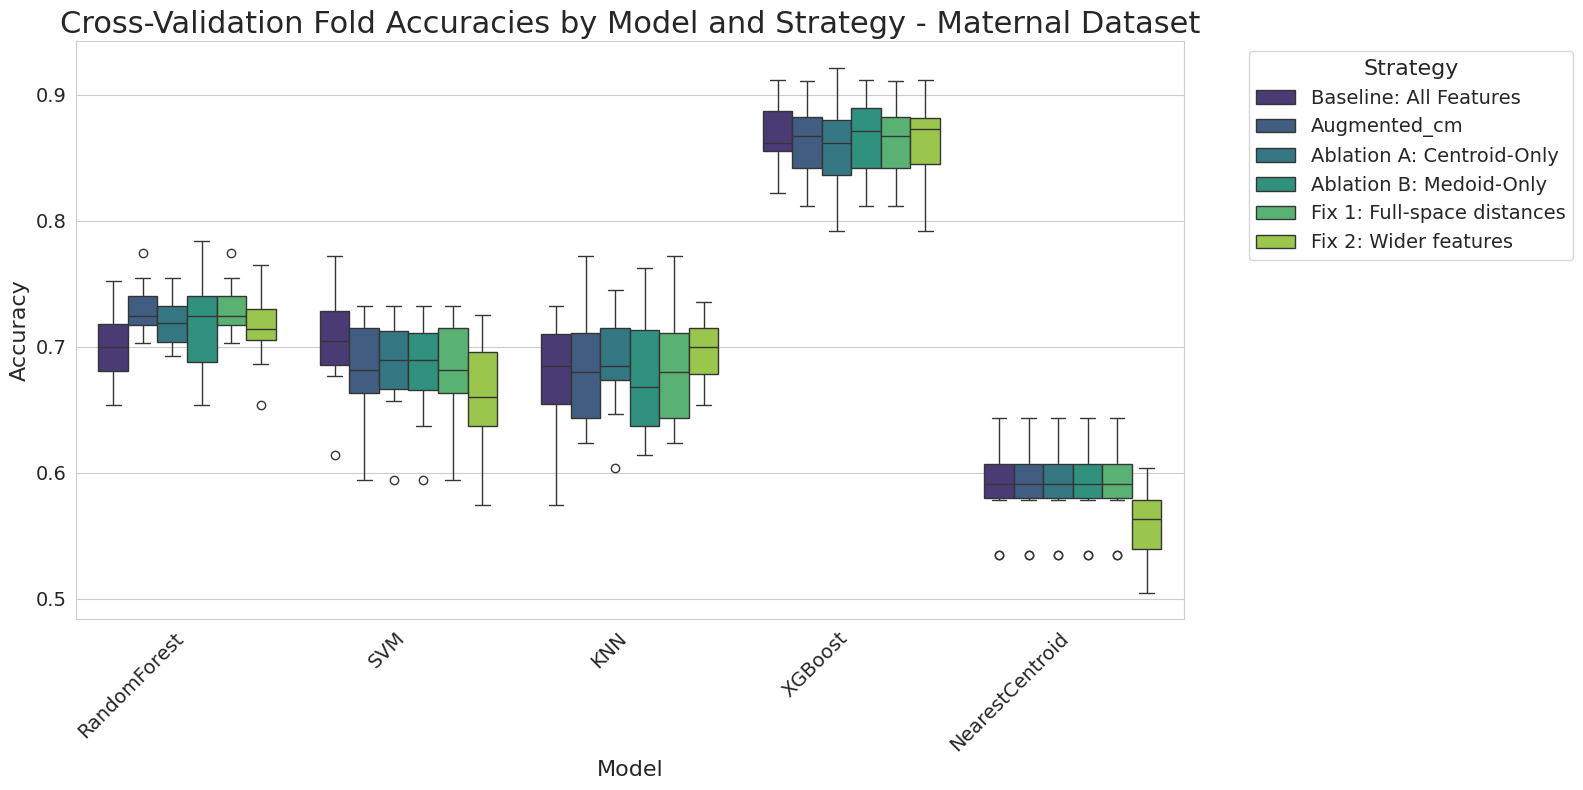

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for boxplot
boxplot_data = []
for result in all_results:
    if '_fold_accuracies' in result:
        model_name = result['Model']
        strategy_name = result['Strategy']
        for acc in result['_fold_accuracies']:
            boxplot_data.append({'Model': model_name, 'Strategy': strategy_name, 'Accuracy': acc})

boxplot_df = pd.DataFrame(boxplot_data)

# Set up the plot
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Create the boxplot
sns.boxplot(data=boxplot_df, x='Model', y='Accuracy', hue='Strategy', palette='viridis')

# Customize plot titles and labels
plt.title('Cross-Validation Fold Accuracies by Model and Strategy - Maternal Dataset', fontsize=22) # Increased title fontsize
plt.xlabel('Model', fontsize=16) # Increased x-label fontsize
plt.ylabel('Accuracy', fontsize=16) # Increased y-label fontsize
plt.xticks(rotation=45, ha='right', fontsize=14) # Increased x-tick fontsize
plt.yticks(fontsize=14) # Increased y-tick fontsize
plt.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=16) # Increased legend font sizes
plt.tight_layout()
plt.show()